## Business Problem Statement: An educational institution wants to improve student performance by identifying factors that influence academic success.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
education_data = pd.read_csv('/content/student_performance_data.csv')

In [10]:
education_data.head()

,StudentID,Age,Gender,SocioeconomicStatus,Grades,Attendance,TimeSpentOnHomework,ClassParticipation,AcademicPerformanceStatus
0,S0001,21,Female,High,73.821849,99.578045,3.153141,Medium,Pass
1,S0002,18,Female,Low,61.301450,95.580772,3.160019,Medium,Pass
2,S0003,19,Female,Low,82.023802,74.858691,1.594093,Low,Pass
3,S0004,21,Male,Low,98.949056,67.806661,1.937389,Medium,Pass
4,S0005,17,Female,Middle,80.174655,79.575701,1.233916,High,Pass


## Summary of Data

### Column Descriptions

`StudentID`: Unique identifier for each student.

`Age`: Student's age.

`Gender`: Student's gender.

`SocioeconomicStatus`: Student's socioeconomic status (Low, Middle, High).

`Grades`: Student's average grades.

`Attendance`: Student's attendance percentage.

`TimeSpentOnHomework`: Average time spent on homework per day.

`ClassParticipation`: Level of participation in class (Low, Medium, High).

`AcademicPerformanceStatus`: Whether the student passed or failed (Pass/Fail)

Issue with the Dataset

Wrong Datatype assigned to AcademicPerformanceStatus,Gender,SocioeconomicStatus and ClassParticipation

In [11]:
education_data.tail()

,StudentID,Age,Gender,SocioeconomicStatus,Grades,Attendance,TimeSpentOnHomework,ClassParticipation,AcademicPerformanceStatus
995,S0996,20,Female,High,88.852464,65.525012,3.427325,Medium,Pass
996,S0997,15,Male,High,93.110149,94.364470,3.910538,Medium,Pass
997,S0998,21,Female,Middle,65.693775,80.002330,3.914607,Medium,Pass
998,S0999,18,Male,High,76.901135,86.995728,0.728469,Low,Pass
999,S1000,20,Female,Middle,92.005404,69.562655,3.376438,Low,Pass


In [14]:
education_data.sample(5)

,StudentID,Age,Gender,SocioeconomicStatus,Grades,Attendance,TimeSpentOnHomework,ClassParticipation,AcademicPerformanceStatus
151,S0152,20,Female,Middle,69.900265,74.900357,1.268722,Low,Pass
760,S0761,19,Female,Middle,59.748760,85.758263,1.561269,Medium,Fail
428,S0429,21,Female,Low,89.834070,92.217293,2.157025,Low,Pass
31,S0032,15,Male,Low,50.006735,68.748392,3.129476,Low,Fail
456,S0457,20,Female,Middle,81.614108,74.418980,0.924560,Low,Pass


In [15]:
education_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  1000 non-null   object 
 1   Age                        1000 non-null   int64  
 2   Gender                     1000 non-null   object 
 3   SocioeconomicStatus        1000 non-null   object 
 4   Grades                     1000 non-null   float64
 5   Attendance                 1000 non-null   float64
 6   TimeSpentOnHomework        1000 non-null   float64
 7   ClassParticipation         1000 non-null   object 
 8   AcademicPerformanceStatus  1000 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 70.4+ KB


In [19]:
missing_values = education_data.isnull().sum()
print(missing_values)

StudentID                    0
Age                          0
Gender                       0
SocioeconomicStatus          0
Grades                       0
Attendance                   0
TimeSpentOnHomework          0
ClassParticipation           0
AcademicPerformanceStatus    0
dtype: int64


In [16]:
education_data.duplicated().sum()

0

In [17]:
education_data.describe()

,Age,Grades,Attendance,TimeSpentOnHomework
count,1000.0000,1000.000000,1000.000000,1000.000000
mean,17.9600,74.892793,79.448395,2.245859
std,2.0036,14.428974,11.417765,1.009563
min,15.0000,50.000582,60.001229,0.500795
25%,16.0000,62.442623,69.451976,1.400813
50%,18.0000,75.155411,79.329503,2.191778
75%,20.0000,87.201111,89.137688,3.131317
max,21.0000,99.944631,99.982308,3.995775


Checking if the columns can be converted to Categorical

In [20]:
print("AcademicPerformanceStatus:", education_data['AcademicPerformanceStatus'].unique())
print("Gender:", education_data['Gender'].unique())
print("SocioeconomicStatus:", education_data['SocioeconomicStatus'].unique())
print("ClassParticipation:", education_data['ClassParticipation'].unique())

AcademicPerformanceStatus: ['Pass' 'Fail']
Gender: ['Female' 'Male']
SocioeconomicStatus: ['High' 'Low' 'Middle']
ClassParticipation: ['Medium' 'Low' 'High']


In [21]:
education_data['AcademicPerformanceStatus'] = education_data['AcademicPerformanceStatus'].astype('category')
education_data['Gender'] = education_data['Gender'].astype('category')
education_data['SocioeconomicStatus'] = education_data['SocioeconomicStatus'].astype('category')
education_data['ClassParticipation'] = education_data['ClassParticipation'].astype('category')

In [22]:
education_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   StudentID                  1000 non-null   object  
 1   Age                        1000 non-null   int64   
 2   Gender                     1000 non-null   category
 3   SocioeconomicStatus        1000 non-null   category
 4   Grades                     1000 non-null   float64 
 5   Attendance                 1000 non-null   float64 
 6   TimeSpentOnHomework        1000 non-null   float64 
 7   ClassParticipation         1000 non-null   category
 8   AcademicPerformanceStatus  1000 non-null   category
dtypes: category(4), float64(3), int64(1), object(1)
memory usage: 43.6+ KB


## EDA

### Performing Univariate Analysis on Categorical Variable

### AcademicPerformanceStatus

**conclusions**

* The pie chart shows around 80.6% of students pass, which is pretty good overall
* But nearly 20% fail, which is concerning and worth looking into
* This split gives us a starting point to dig into what might be causing the failures and how to improve things

In [24]:
# Frequency count for AcademicPerformanceStatus
aps_counts = education_data['AcademicPerformanceStatus'].value_counts()
print(aps_counts)

AcademicPerformanceStatus
Pass    806
Fail    194
Name: count, dtype: int64


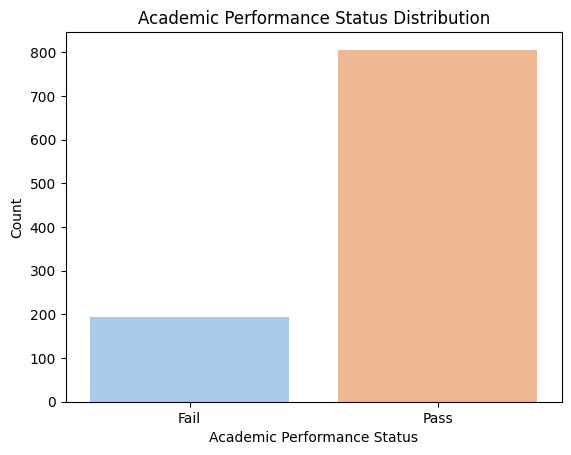

In [28]:
sns.countplot(data=education_data, x='AcademicPerformanceStatus', hue='AcademicPerformanceStatus', palette='pastel')
plt.title('Academic Performance Status Distribution')
plt.xlabel('Academic Performance Status')
plt.ylabel('Count')
plt.show()

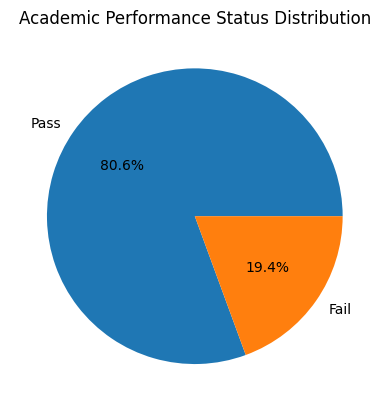

In [30]:
plt.pie(aps_counts, labels=aps_counts.index, autopct='%0.1f%%',)
plt.title('Academic Performance Status Distribution')
plt.show()

###Gender

**conclusions**

* The pie chart shows an almost even split—about 50.7% male and 49.3% female
* This near balance means gender isn’t likely a major confounding factor in academic performance analysis

In [31]:
gender_counts = education_data['Gender'].value_counts()
print(gender_counts)

Gender
Male      507
Female    493
Name: count, dtype: int64


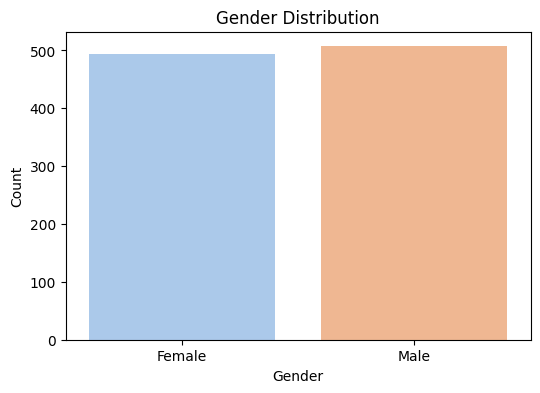

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(data=education_data, x='Gender', hue='Gender', palette='pastel')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

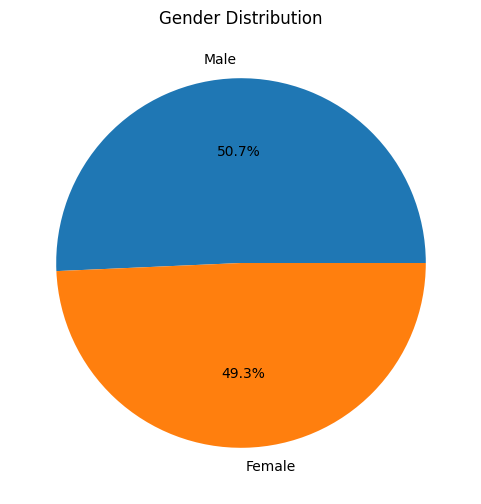

In [34]:
plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%0.1f%%', )
plt.title('Gender Distribution')
plt.show()

### SocioeconomicStatus

**conclusions**
* The pie chart shows that about 50.6% of students are in the Middle category, 29.6% in Low, and 19.8% in High
* So, most of our students fall into the Middle socioeconomic group, with fewer in the High group
* This split gives us a good snapshot of the socioeconomic makeup for further analysis on its impact on academic performance

In [35]:
ses_counts = education_data['SocioeconomicStatus'].value_counts()
print(ses_counts)

SocioeconomicStatus
Middle    506
Low       296
High      198
Name: count, dtype: int64


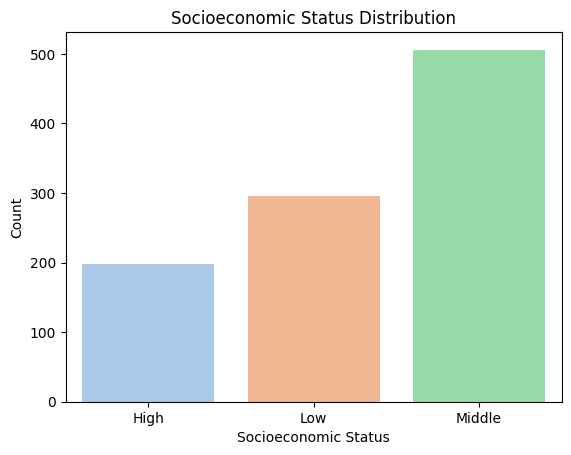

In [36]:
sns.countplot(data=education_data, x='SocioeconomicStatus', hue='SocioeconomicStatus', palette='pastel')
plt.title('Socioeconomic Status Distribution')
plt.xlabel('Socioeconomic Status')
plt.ylabel('Count')
plt.show()

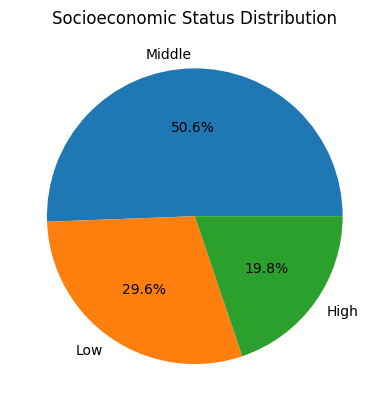

In [37]:
plt.pie(ses_counts, labels=ses_counts.index, autopct='%0.1f%%')
plt.title('Socioeconomic Status Distribution')
plt.show()

### ClassParticipation

**conclusions**

* The pie chart shows that about 48.6% of students have Medium participation, 29.9% have High, and only 21.5% fall into the Low category
* So, most students are pretty engaged in class, while a smaller group is less involved
* This gives us a good picture of class participation levels to explore its impact on academic performance later

In [38]:
cp_counts = education_data['ClassParticipation'].value_counts()
print(cp_counts)

ClassParticipation
Medium    486
High      299
Low       215
Name: count, dtype: int64


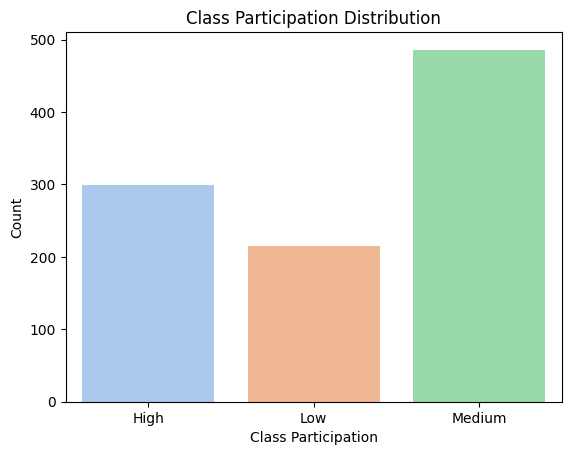

In [39]:
sns.countplot(data=education_data, x='ClassParticipation', hue='ClassParticipation', palette='pastel')
plt.title('Class Participation Distribution')
plt.xlabel('Class Participation')
plt.ylabel('Count')
plt.show()

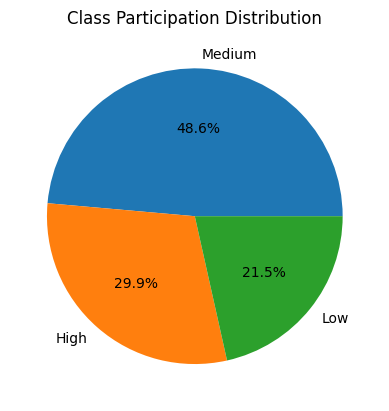

In [40]:
plt.pie(cp_counts, labels=cp_counts.index, autopct='%0.1f%%')
plt.title('Class Participation Distribution')
plt.show()

## Performing Univariate analysis on Numerical columns

### Grades

**conclusions**

* Even though the average and median are around 75, the histogram (with various bin sizes) consistently shows the most frequent range is around 61–65
* This suggests that while many students score higher, a large group tends to cluster in the low 60s, which might be an interesting sub-group to explore further
* while box plot shows no outliers

In [44]:
final_exam_summary = education_data['Grades'].describe()
print("Summary for Grades:")
print(final_exam_summary)

Summary for Grades:
count    1000.000000
mean       74.892793
std        14.428974
min        50.000582
25%        62.442623
50%        75.155411
75%        87.201111
max        99.944631
Name: Grades, dtype: float64


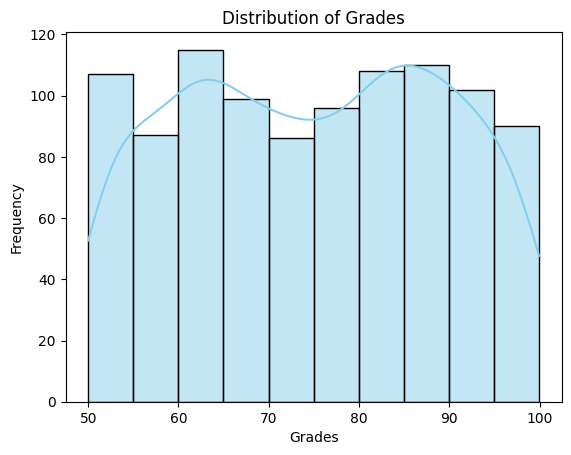

In [50]:
sns.histplot(education_data['Grades'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Grades')
plt.xlabel('Grades')
plt.ylabel('Frequency')
plt.show()

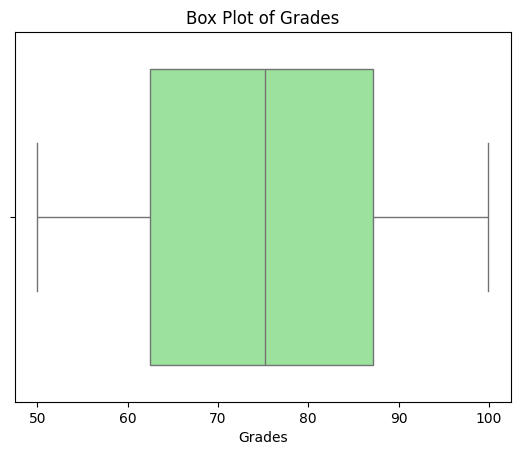

In [46]:
sns.boxplot(x=education_data['Grades'], color='lightgreen')
plt.title('Box Plot of Grades')
plt.xlabel('Grades')
plt.show()

### Attendance

**conclusions**

* The histogram consistently shows that the highest frequency of attendance falls around 83-84%, meaning most students have high attendance
* The box plot confirms there aren’t any extreme outliers, so attendance is pretty stable
* Overall, it seems like students generally maintain a good attendance rate

In [51]:
attendance_summary = education_data['Attendance'].describe()
print("Attendance Summary:")
print(attendance_summary)

Attendance Summary:
count    1000.000000
mean       79.448395
std        11.417765
min        60.001229
25%        69.451976
50%        79.329503
75%        89.137688
max        99.982308
Name: Attendance, dtype: float64


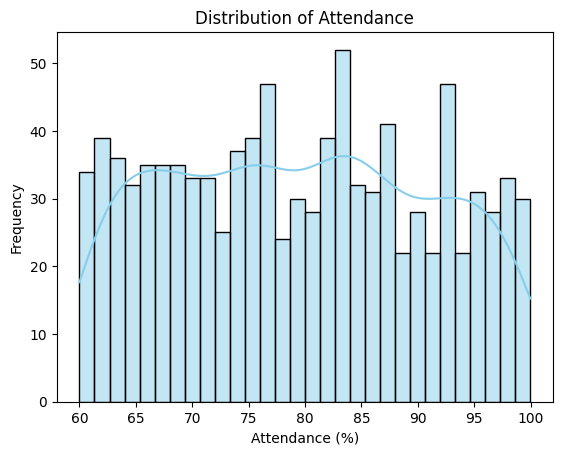

In [55]:
sns.histplot(education_data['Attendance'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Attendance')
plt.xlabel('Attendance (%)')
plt.ylabel('Frequency')
plt.show()

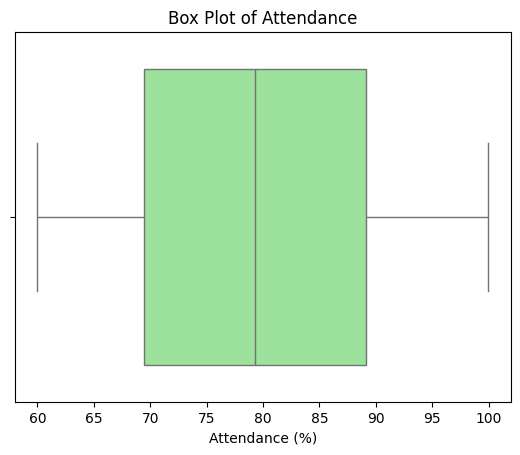

In [53]:
sns.boxplot(x=education_data['Attendance'], color='lightgreen')
plt.title('Box Plot of Attendance')
plt.xlabel('Attendance (%)')
plt.show()

### TimeSpentOnHomework

**conclusions**

* The histogram shows that most students spend around 1.7 hours on homework, which seems to be the most common value
* The overall distribution is fairly normal with no significant outliers as confirmed by the box plot

In [56]:
homework_summary = education_data['TimeSpentOnHomework'].describe()
print("Time Spent On Homework Summary:")
print(homework_summary)

Time Spent On Homework Summary:
count    1000.000000
mean        2.245859
std         1.009563
min         0.500795
25%         1.400813
50%         2.191778
75%         3.131317
max         3.995775
Name: TimeSpentOnHomework, dtype: float64


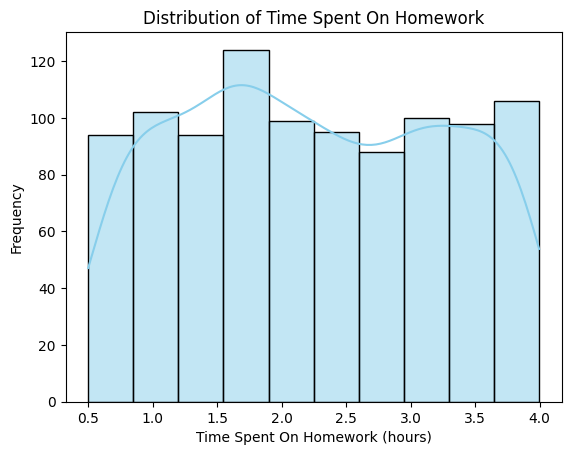

In [62]:
sns.histplot(education_data['TimeSpentOnHomework'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Time Spent On Homework')
plt.xlabel('Time Spent On Homework (hours)')
plt.ylabel('Frequency')
plt.show()

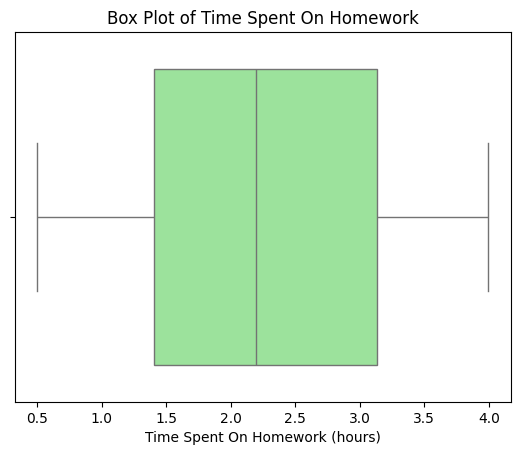

In [58]:
sns.boxplot(x=education_data['TimeSpentOnHomework'], color='lightgreen')
plt.title('Box Plot of Time Spent On Homework')
plt.xlabel('Time Spent On Homework (hours)')
plt.show()

In [63]:
skewness_homework = education_data['TimeSpentOnHomework'].skew()
print("Skewness for TimeSpentOnHomework:", skewness_homework)

Skewness for TimeSpentOnHomework: 0.054903971441584


### Age

**conclusions**

* The histogram with 10 bins shows two major peaks around age 15 and 18, indicating these are the most common age groups
* The skewness is nearly zero (-0.00034), meaning the distribution is symmetric
* The data suggests a balanced age distribution

In [64]:
age_summary = education_data['Age'].describe()
print("Age Summary:")
print(age_summary)

Age Summary:
count    1000.0000
mean       17.9600
std         2.0036
min        15.0000
25%        16.0000
50%        18.0000
75%        20.0000
max        21.0000
Name: Age, dtype: float64


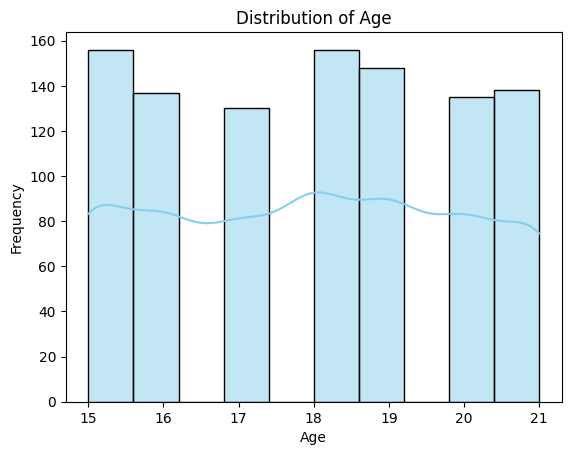

In [72]:
sns.histplot(education_data['Age'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

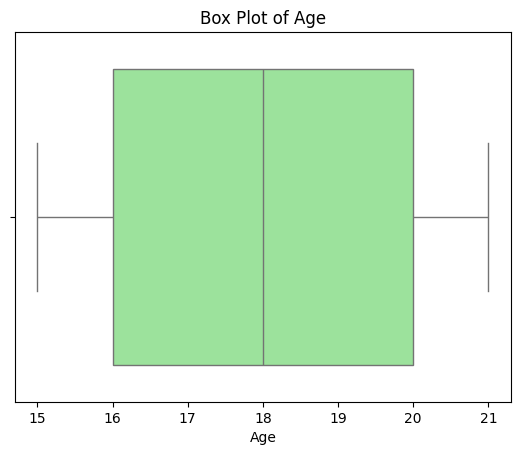

In [73]:
sns.boxplot(x=education_data['Age'], color='lightgreen')
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.show()

In [74]:
skewness_age = education_data['Age'].skew()
print("Skewness for Age:", skewness_age)

Skewness for Age: -0.00033519685084168016


### Performing Bivariate Analysis on Categorical vs Numerical Columns

### Grades vs. Gender

**conclusions**

* The bar chart shows that average grades are pretty close between genders, with females averaging around 74.64 and males around 75.13
* The slight difference isn't huge, suggesting gender doesn't have a strong impact on grades

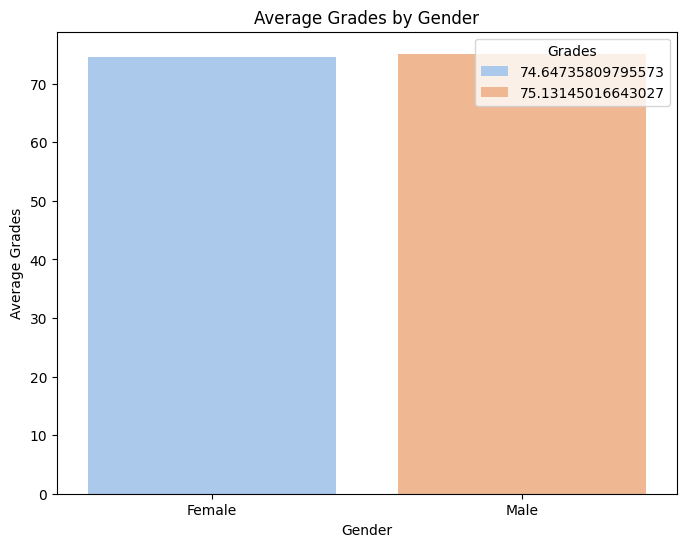

In [114]:
# Compute average Grades for each Gender
avg_grades_by_gender = education_data.groupby('Gender',observed=False)['Grades'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=avg_grades_by_gender, x='Gender', y='Grades',hue = 'Grades', palette='pastel')
plt.title("Average Grades by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Grades")
plt.show()

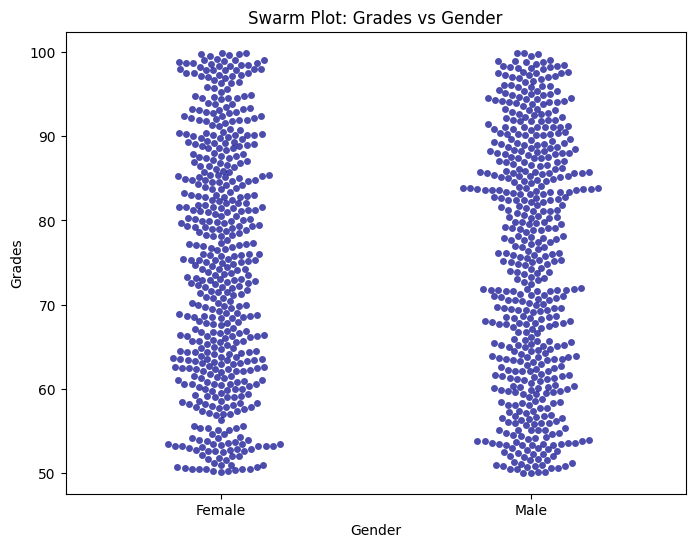

In [128]:
plt.figure(figsize=(8,6))
sns.swarmplot(data=education_data, x='Gender', y='Grades', color='darkblue', alpha=0.7)
plt.title("Swarm Plot: Grades vs Gender")
plt.xlabel("Gender")
plt.ylabel("Grades")
plt.show()

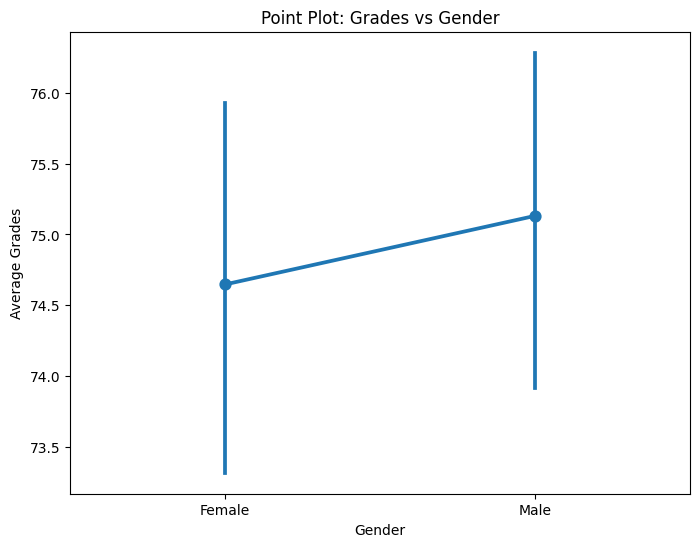

In [107]:
plt.figure(figsize=(8,6))
sns.pointplot(data=education_data, x='Gender', y='Grades')
plt.title("Point Plot: Grades vs Gender")
plt.xlabel("Gender")
plt.ylabel("Average Grades")
plt.show()

### Grades by Socioeconomic Status

**conclusions**

* The violin plot shows each socioeconomic group has its own spread of grades, with “Middle” leaning a bit higher overall.
* The swarm plot backs that up—“Middle” grades cluster slightly higher, while “High” and “Low” groups spread across the board.
* It looks like socioeconomic status does influence grades somewhat, though the gap isn’t massive

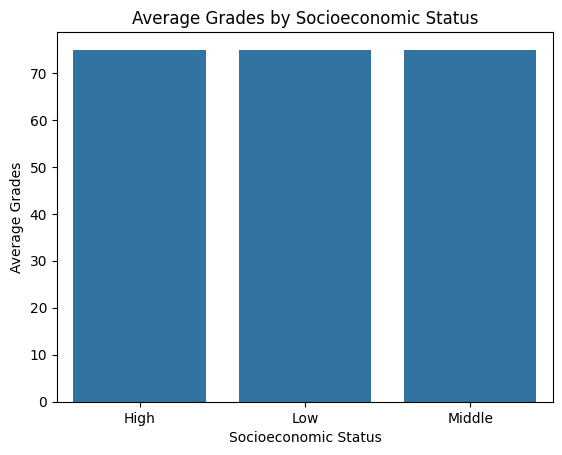

In [110]:
avg_grades_by_ses = education_data.groupby('SocioeconomicStatus', observed=False)['Grades'].mean().reset_index()

sns.barplot(data=avg_grades_by_ses, x='SocioeconomicStatus', y='Grades')
plt.title("Average Grades by Socioeconomic Status")
plt.xlabel("Socioeconomic Status")
plt.ylabel("Average Grades")
plt.show()

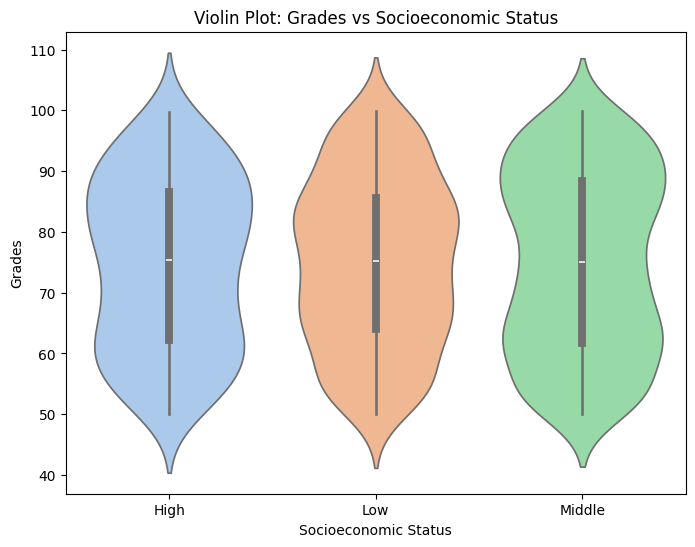

In [112]:
plt.figure(figsize=(8,6))
sns.violinplot(data=education_data, x='SocioeconomicStatus', y='Grades',hue='SocioeconomicStatus', palette='pastel')
plt.title("Violin Plot: Grades vs Socioeconomic Status")
plt.xlabel("Socioeconomic Status")
plt.ylabel("Grades")
plt.show()

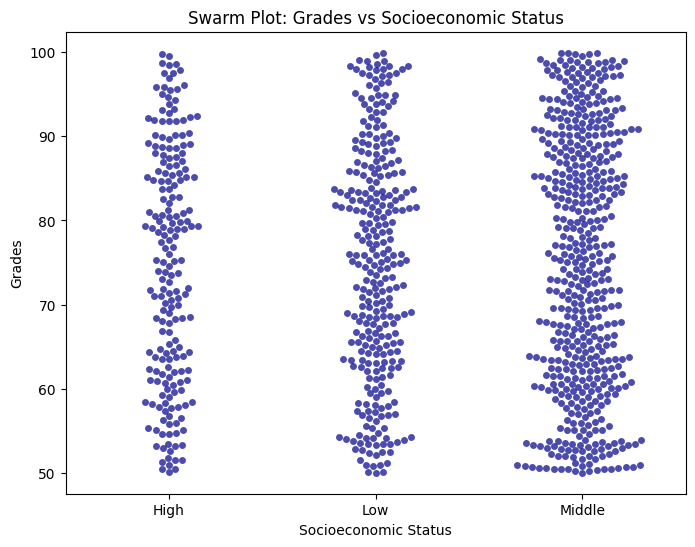

In [115]:
plt.figure(figsize=(8,6))
sns.swarmplot(data=education_data, x='SocioeconomicStatus', y='Grades', color='darkblue', alpha=0.7)
plt.title("Swarm Plot: Grades vs Socioeconomic Status")
plt.xlabel("Socioeconomic Status")
plt.ylabel("Grades")
plt.show()

### Grades vs. ClassParticipation

**conclusions**

* The violin plot shows all three participation levels have a broad spread of grades, with no drastic difference in medians
* The swarm plot reveals that Medium has the largest cluster of students, while High and Low have fewer but still a wide range of grades
* It looks like class participation may affect performance

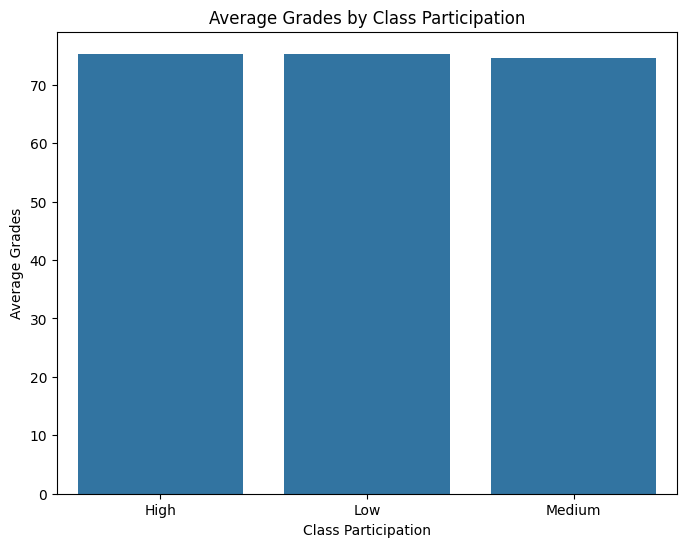

In [117]:
avg_grades_by_participation = education_data.groupby('ClassParticipation',observed=False)['Grades'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=avg_grades_by_participation, x='ClassParticipation', y='Grades')
plt.title("Average Grades by Class Participation")
plt.xlabel("Class Participation")
plt.ylabel("Average Grades")
plt.show()

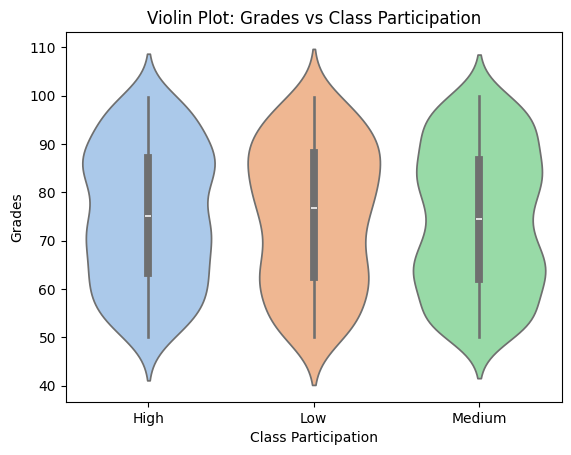

In [122]:
sns.violinplot(data=education_data, x='ClassParticipation', y='Grades',hue='ClassParticipation', palette='pastel')
plt.title("Violin Plot: Grades vs Class Participation")
plt.xlabel("Class Participation")
plt.ylabel("Grades")
plt.show()

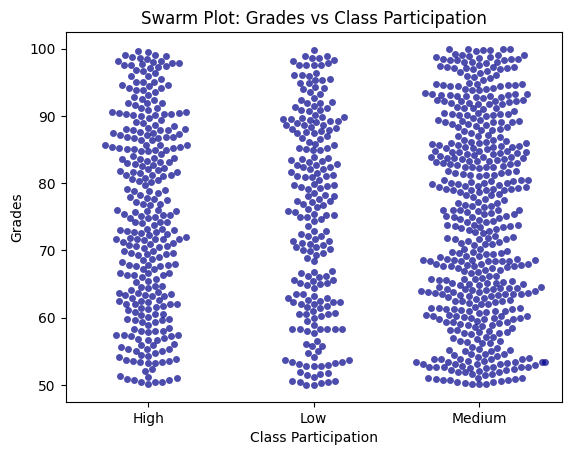

In [123]:
sns.swarmplot(data=education_data, x='ClassParticipation', y='Grades', color='darkblue', alpha=0.7)
plt.title("Swarm Plot: Grades vs Class Participation")
plt.xlabel("Class Participation")
plt.ylabel("Grades")
plt.show()

### TimeSpentOnHomework  versus  Average of AcademicPerformanceStatus

**conclusions**

* The violin plots show both Fail and Pass have similar medians, but the Pass group has a slightly wider range overall
* The swarm plot makes it clear that Pass is spread out across more homework time values, while Fail is somewhat more clustered
* This suggests that among those who pass, there's a broader variety of homework habits, whereas those who fail tend to group more narrowly around certain time ranges

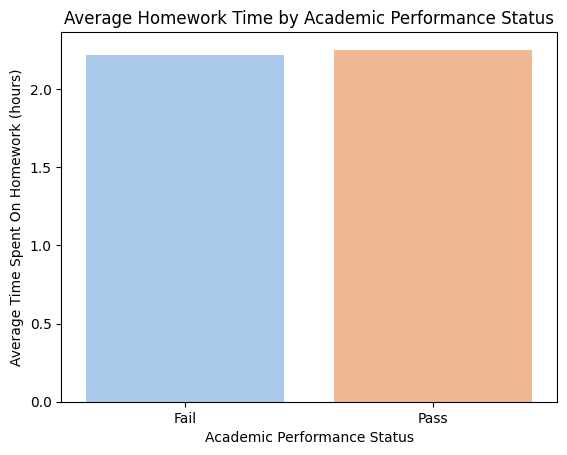

In [150]:
avg_homework_by_perf = education_data.groupby('AcademicPerformanceStatus',observed=False)['TimeSpentOnHomework'].mean().reset_index()

sns.barplot(data=avg_homework_by_perf, x='AcademicPerformanceStatus', y='TimeSpentOnHomework', hue='AcademicPerformanceStatus', palette='pastel')
plt.title("Average Homework Time by Academic Performance Status")
plt.xlabel("Academic Performance Status")
plt.ylabel("Average Time Spent On Homework (hours)")
plt.show()

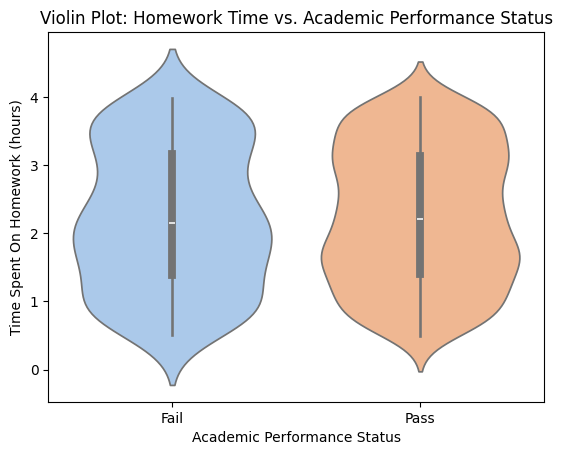

In [153]:
sns.violinplot(data=education_data, x='AcademicPerformanceStatus', y='TimeSpentOnHomework',hue='AcademicPerformanceStatus', palette='pastel')
plt.title("Violin Plot: Homework Time vs. Academic Performance Status")
plt.xlabel("Academic Performance Status")
plt.ylabel("Time Spent On Homework (hours)")
plt.show()

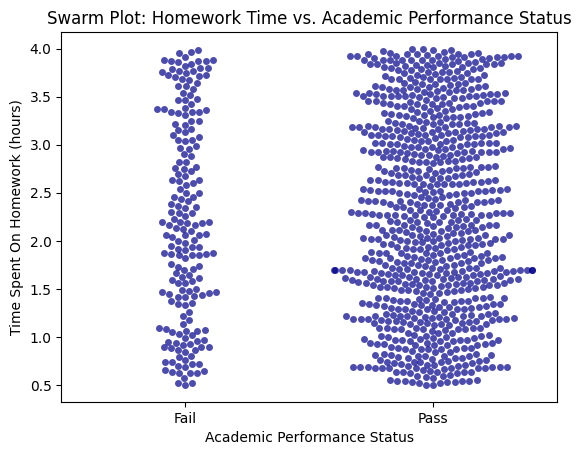

In [154]:
sns.swarmplot(data=education_data, x='AcademicPerformanceStatus', y='TimeSpentOnHomework', color='darkblue', alpha=0.7)
plt.title("Swarm Plot: Homework Time vs. Academic Performance Status")
plt.xlabel("Academic Performance Status")
plt.ylabel("Time Spent On Homework (hours)")
plt.show()

### Performing Bivariate Analysis on Categorical vs Categorical Columns

### AcademicPerformanceStatus (Pass/Fail) vs. Gender

**conclusions**
* For females, the heatmap shows 92 fails and 401 passes, while for males there are 102 fails and 405 passes
* This suggests that the pass/fail rates are quite similar across genders, with roughly 81% pass for females and 80% for males
* Overall, gender doesn't seem to be a major factor in academic performance based on these numbers

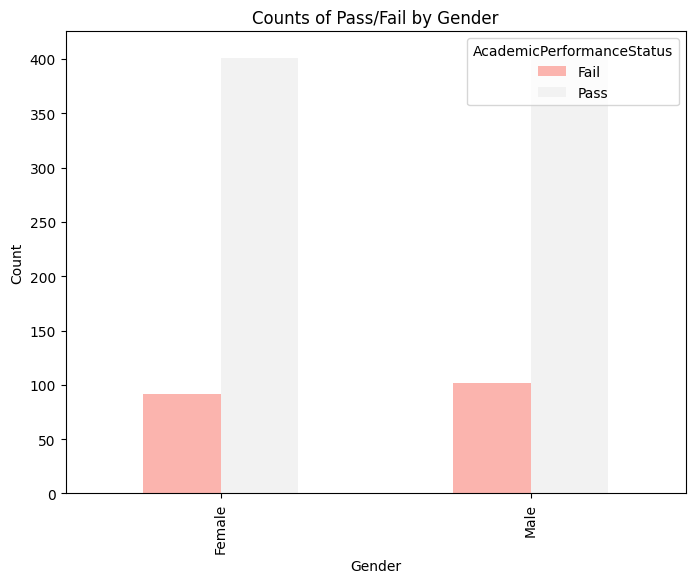

In [125]:
# Create a crosstab of Gender vs. AcademicPerformanceStatus
gender_perform = pd.crosstab(education_data['Gender'], education_data['AcademicPerformanceStatus'])

gender_perform.plot(kind='bar', figsize=(8,6), colormap='Pastel1')
plt.title('Counts of Pass/Fail by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='AcademicPerformanceStatus')
plt.show()


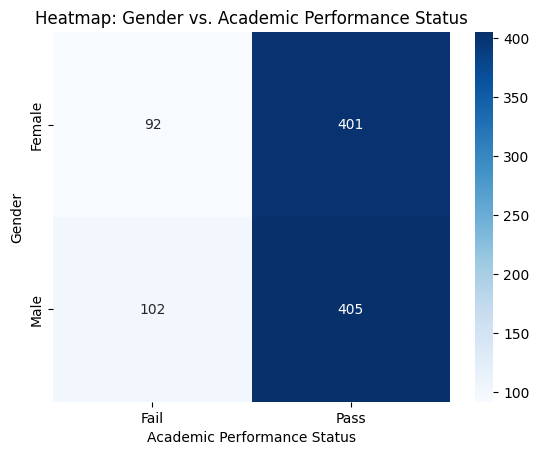

In [129]:
gender_perf_ct = pd.crosstab(education_data['Gender'], education_data['AcademicPerformanceStatus'])

sns.heatmap(gender_perf_ct, annot=True, cmap='Blues', fmt='d')
plt.title("Heatmap: Gender vs. Academic Performance Status")
plt.xlabel("Academic Performance Status")
plt.ylabel("Gender")
plt.show()

### AcademicPerformanceStatus vs. SocioeconomicStatus

**conclusions**

* The heatmap and countplot show that for the High group, there are 39 fails and 159 passes; for Low, 53 fails and 243 passes; and for Middle, 102 fails and 404 passes
* The Middle group is clearly the largest, and while the pass rates are somewhat consistent across groups, the sheer numbers in Middle stand out
* Overall, it seems like socioeconomic status might have a minor effect on academic performance

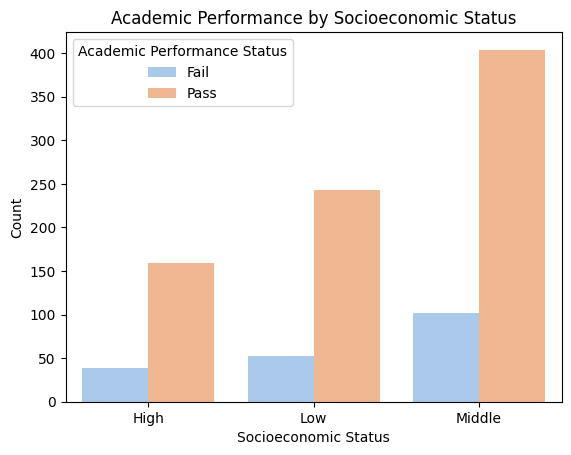

In [132]:
sns.countplot(data=education_data, x='SocioeconomicStatus', hue='AcademicPerformanceStatus', palette='pastel')
plt.title("Academic Performance by Socioeconomic Status")
plt.xlabel("Socioeconomic Status")
plt.ylabel("Count")
plt.legend(title="Academic Performance Status")
plt.show()

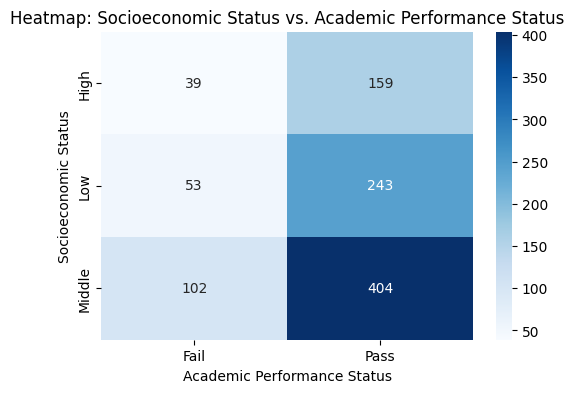

In [133]:
ses_perf_ct = pd.crosstab(education_data['SocioeconomicStatus'], education_data['AcademicPerformanceStatus'])

plt.figure(figsize=(6,4))
sns.heatmap(ses_perf_ct, annot=True, cmap='Blues', fmt='d')
plt.title("Heatmap: Socioeconomic Status vs. Academic Performance Status")
plt.xlabel("Academic Performance Status")
plt.ylabel("Socioeconomic Status")
plt.show()

### AcademicPerformanceStatus vs. ClassParticipation

**conclusions**

* The plots show that every participation level (High, Medium, Low) has more passes than fails, with Medium being the largest group
* The ratios are fairly similar across groups, which suggests that while class participation might influence performance, it doesn't appear to be a major factor on its own

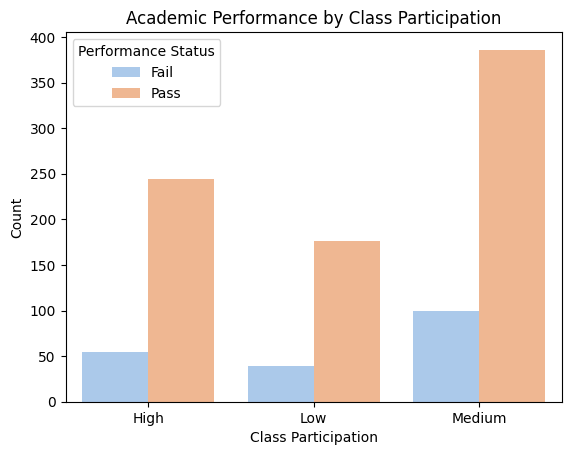

In [134]:
sns.countplot(data=education_data, x='ClassParticipation', hue='AcademicPerformanceStatus', palette='pastel')
plt.title("Academic Performance by Class Participation")
plt.xlabel("Class Participation")
plt.ylabel("Count")
plt.legend(title="Performance Status")
plt.show()

In [135]:
cp_perform = pd.crosstab(education_data['ClassParticipation'], education_data['AcademicPerformanceStatus'])
print(cp_perform)

AcademicPerformanceStatus  Fail  Pass
ClassParticipation                   
High                         55   244
Low                          39   176
Medium                      100   386


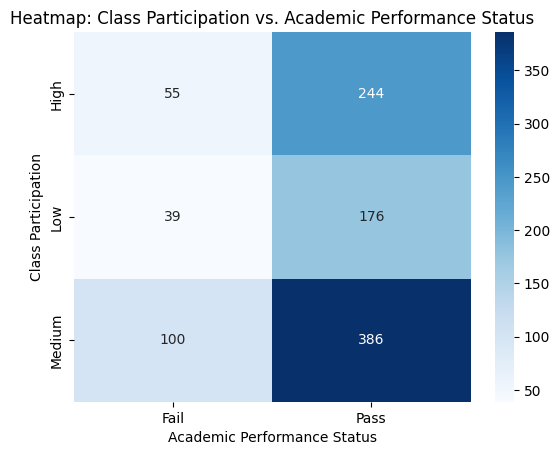

In [136]:
sns.heatmap(cp_perform, annot=True, cmap='Blues', fmt='d')
plt.title("Heatmap: Class Participation vs. Academic Performance Status")
plt.xlabel("Academic Performance Status")
plt.ylabel("Class Participation")
plt.show()

Performing Bivariate Analysis on numerical vs Numerical Columns

### Grades vs Attendance

**conclusions**

* The scatter plot for Grades vs. Attendance is pretty scattered, showing no clear trend
* The correlation matrix shows a correlation of -0.02, which is effectively zero
* Overall, attendance doesn't seem to influence grades

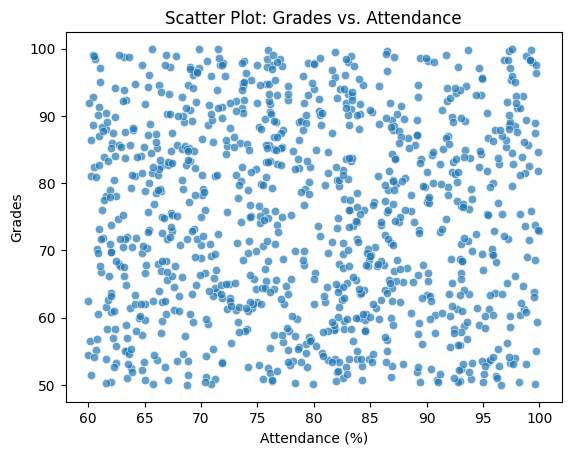

In [137]:
sns.scatterplot(data=education_data, x='Attendance', y='Grades', alpha=0.7)
plt.title("Scatter Plot: Grades vs. Attendance")
plt.xlabel("Attendance (%)")
plt.ylabel("Grades")
plt.show()

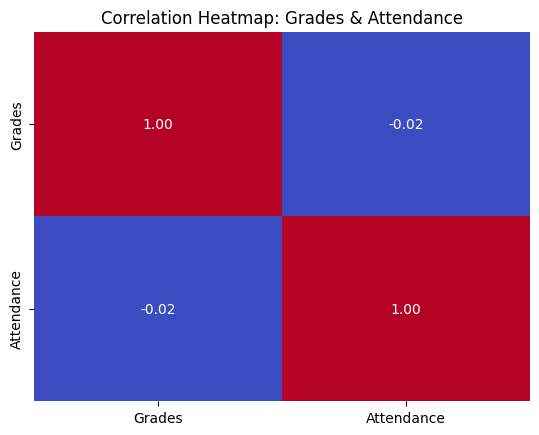

In [146]:
num_cols = ['Grades', 'Attendance']
corr_matrix = education_data[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=False)
plt.title("Correlation Heatmap: Grades & Attendance")
plt.show()

In [140]:
corr_gr_Att =  education_data['Grades'].corr( education_data['Attendance'])
print("Correlation (Humidity & EnergyConsumption):", corr_gr_Att)

Correlation (Humidity & EnergyConsumption): -0.022231665068540612


### Grades vs Age

**conclusions**

* The scatter plot shows that for each age (15, 16, …, 21), the data points are tightly grouped, resulting in a nearly straight-line appearance
* The correlation of only 0.01 confirms that there's virtually no relationship between age and grades

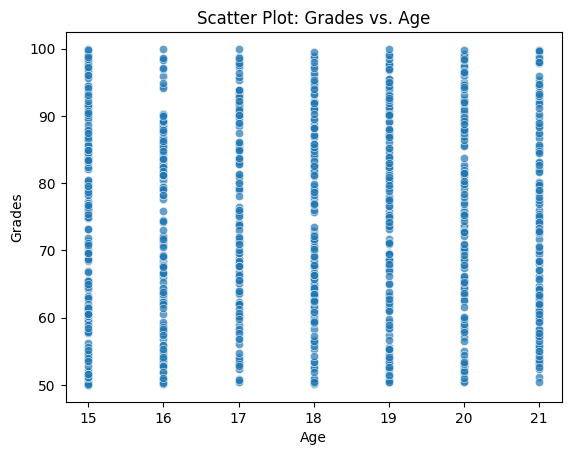

In [141]:
sns.scatterplot(data=education_data, x='Age', y='Grades', alpha=0.7)
plt.title("Scatter Plot: Grades vs. Age")
plt.xlabel("Age")
plt.ylabel("Grades")
plt.show()

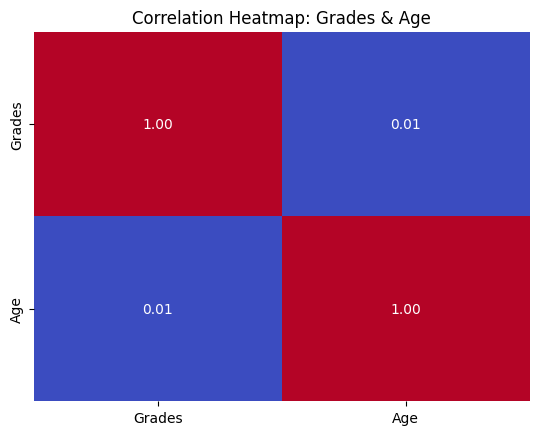

In [145]:
num_cols = ['Grades', 'Age']
corr_matrix = education_data[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=False)
plt.title("Correlation Heatmap: Grades & Age")
plt.show()

### Attendance and TimeSpentOnHomework

**conclusions**

* The scatter plot for Attendance vs. TimeSpentOnHomework shows a fairly random spread of points
* The correlation is about -0.07, which is basically zero, indicating no meaningful relationship
* Overall, it seems attendance and time spent on homework don't really influence with each other

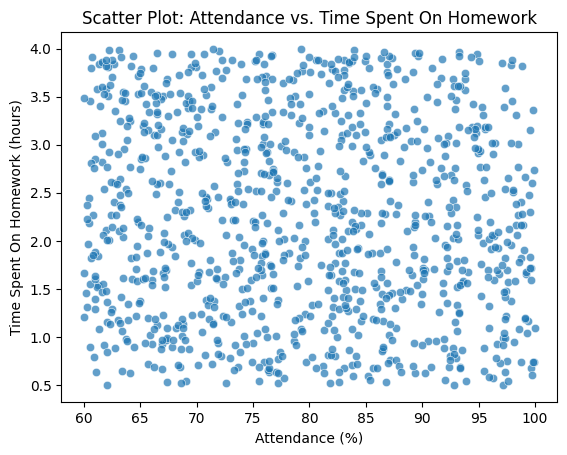

In [143]:
sns.scatterplot(data=education_data, x='Attendance', y='TimeSpentOnHomework', alpha=0.7)
plt.title("Scatter Plot: Attendance vs. Time Spent On Homework")
plt.xlabel("Attendance (%)")
plt.ylabel("Time Spent On Homework (hours)")
plt.show()

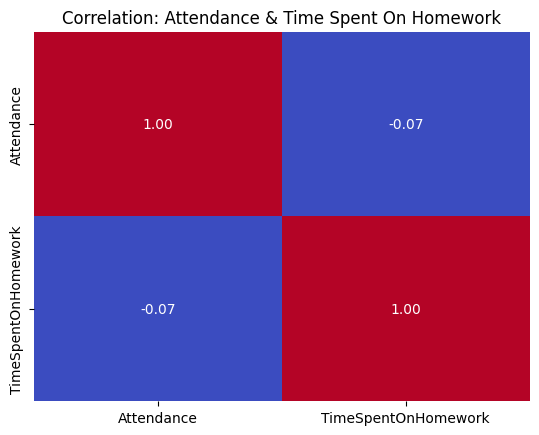

In [144]:
num_cols = ['Attendance', 'TimeSpentOnHomework']
corr_matrix = education_data[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=False)
plt.title("Correlation: Attendance & Time Spent On Homework")
plt.show()

### TimeSpentOnHomework and Age

**conclusion**

* For ages 16 to 21, the scatter plot shows points forming almost straight lines, meaning each age group has similar homework times
* The correlation of 0.03 confirms there's essentially no relationship between age and time spent on homework

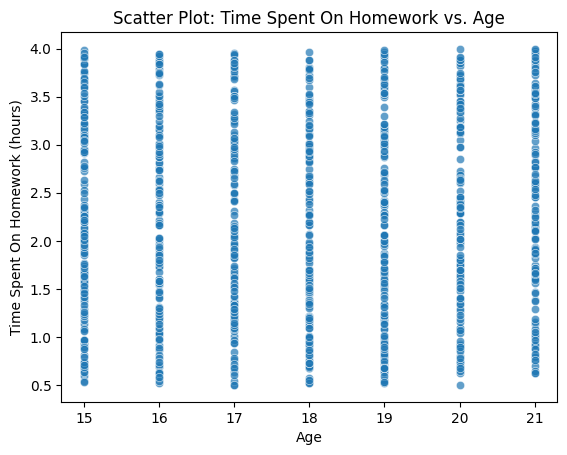

In [147]:
sns.scatterplot(data=education_data, x='Age', y='TimeSpentOnHomework', alpha=0.7)
plt.title("Scatter Plot: Time Spent On Homework vs. Age")
plt.xlabel("Age")
plt.ylabel("Time Spent On Homework (hours)")
plt.show()

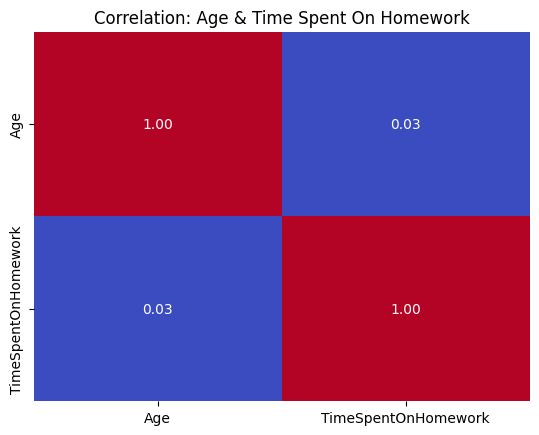

In [148]:
num_cols = ['Age', 'TimeSpentOnHomework']
corr_matrix = education_data[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=False)
plt.title("Correlation: Age & Time Spent On Homework")
plt.show()

### Performing Multivariate Analysis

**conclusions**

* The pairplot shows each numeric variable is scattered without any strong trends, and the diagonal KDEs indicate each variable is well-distributed but not tightly linked to the others
* The correlation matrix backs this up, with all correlation values hovering near zero, confirming there are no strong linear relationships among these variables in the dataset

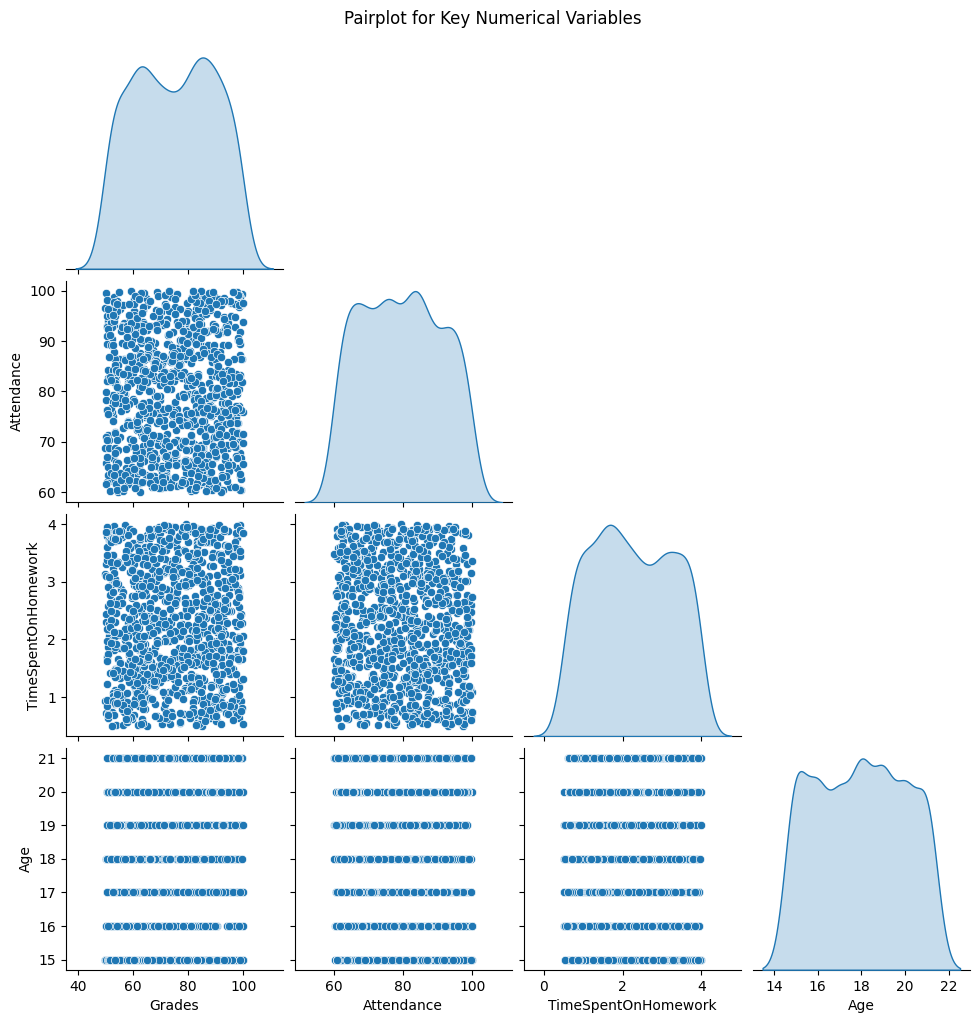

In [156]:
sns.pairplot(education_data[['Grades', 'Attendance', 'TimeSpentOnHomework', 'Age']], diag_kind='kde', corner=True)
plt.suptitle('Pairplot for Key Numerical Variables', y=1.02)
plt.show()

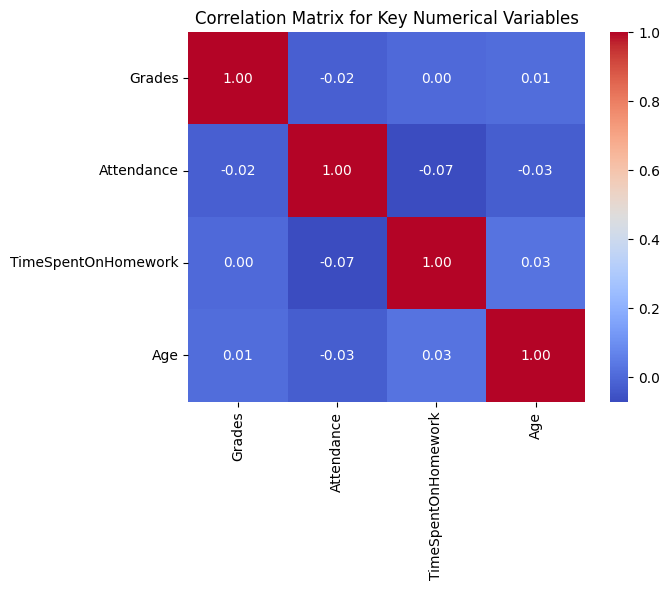

In [157]:
num_cols = ['Grades', 'Attendance', 'TimeSpentOnHomework', 'Age']
corr_matrix = education_data[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix for Key Numerical Variables')
plt.show()

### Final Conclusion

* `Key Insight`:
Our analysis suggests that none of the individual factors (attendance, homework time, age, or even socioeconomic status) have a strong impact on academic performance generally the Pass/fail rates and average grades are similar across genders and socioeconomic groups
-------------------------------------------------------------------------------
* `Implications for Educational Strategies`:
Since the differences are subtle, it may be that academic performance is influenced by a complex interplay of multiple factors which were not captured fully in the current dataset While the attendance and homework time seem important their direct correlations with grades are very weak
-------------------------------------------------------------------------------
* `Next Steps`:
Like We Consider exploring interaction effects or multivariate modeling to see if combinations of factors (or additional variables not yet analyzed) provide more insight into student performance.
We can also explore segmentation or clustering techniques to identify subgroups of students who perform differently based on combined characteristics
-------------------------------------------------------------------------------